# CE 1110 - Generador de señales para la defensa

Genera señales limpias y contaminadas para evaluar el **sistema distribuido de reducción adaptativa de ruido**. El notebook permite configurar casos conocidos o producir una prueba desconocida reproducible mediante una semilla. Exporta WAV de la señal limpia, el ruido y la mezcla, además de metadatos JSON y un ZIP.

> Seguridad: inicie la reproducción con volumen bajo. La salida se normaliza a un pico máximo configurable para evitar saturación digital, pero el nivel eléctrico final depende del equipo de reproducción.

In [1]:
import json, shutil, zipfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, sosfiltfilt, chirp, get_window
from IPython.display import Audio, display

plt.style.use('seaborn-v0_8-whitegrid')
print('Entorno listo')

Entorno listo


## 1. Configuración
Cambie solamente esta celda para preparar una prueba. Use `MODO = 'manual'` para fijar todos los parámetros o `MODO = 'defensa_aleatoria'` para sortear un caso reproducible.

In [2]:
MODO = 'manual'                 # 'manual' o 'defensa_aleatoria'
SEMILLA = 20260918              # guardar para reproducir exactamente la prueba
NOMBRE_PRUEBA = 'defensa_grupo_01'
FS = 16_000                     # Hz
DURACION = 6.0                  # s
PICO_MAXIMO = 0.80              # amplitud digital final
FADE_MS = 20                    # entrada/salida suave

# Señal útil: 'tono', 'multitono', 'chirp', 'armonicos' o 'transitoria'
TIPO_SENAL = 'multitono'
FRECUENCIAS_UTILES = [440, 880, 1320]
AMPLITUDES_UTILES = [1.0, 0.55, 0.30]
FASES_UTILES_GRADOS = [0, 35, -50]

# Ruido: 'tonal', 'red_60hz', 'blanco', 'banda', 'impulsivo' o 'mixto'
TIPO_RUIDO = 'mixto'
SNR_OBJETIVO_DB = 2.0
FRECUENCIA_INTERFERENCIA = 1750  # Hz, para tonal o mixto
BANDA_RUIDO = (2500, 3800)       # Hz, debe quedar bajo FS/2
NUM_IMPULSOS = 10

CARPETA_SALIDA = Path('/kaggle/working/tonos_defensa') if Path('/kaggle/working').exists() else Path('tonos_defensa')
CARPETA_SALIDA

PosixPath('/kaggle/working/tonos_defensa')

## 2. Funciones de generación y medición

In [2]:
def rms(x):
    return float(np.sqrt(np.mean(np.square(x, dtype=np.float64))))

def snr_db(clean, observed):
    error = observed - clean
    return 10*np.log10((np.sum(clean**2)+1e-15)/(np.sum(error**2)+1e-15))

def fade(x, fs, ms=20):
    n = min(int(fs*ms/1000), len(x)//2)
    if n > 0:
        ramp = np.sin(np.linspace(0, np.pi/2, n))**2
        x = x.copy(); x[:n] *= ramp; x[-n:] *= ramp[::-1]
    return x

def normalizar_conjunto(*signals, peak=0.8):
    maximum = max(np.max(np.abs(x)) for x in signals)
    gain = peak/maximum if maximum > 0 else 1.0
    return [x*gain for x in signals], gain

def generar_limpia(kind, t, freqs, amps, phases_deg, rng):
    if kind == 'tono':
        return amps[0]*np.sin(2*np.pi*freqs[0]*t + np.deg2rad(phases_deg[0]))
    if kind == 'multitono':
        return sum(a*np.sin(2*np.pi*f*t + np.deg2rad(p)) for f,a,p in zip(freqs,amps,phases_deg))
    if kind == 'chirp':
        return chirp(t, f0=freqs[0], f1=freqs[-1], t1=t[-1], method='linear')
    if kind == 'armonicos':
        f0 = freqs[0]
        return sum((1/k)*np.sin(2*np.pi*k*f0*t + rng.uniform(-np.pi,np.pi)) for k in range(1,6))
    if kind == 'transitoria':
        env = np.exp(-5*(t % 1.0))*(np.sin(2*np.pi*2*t)>0)
        return env*np.sin(2*np.pi*freqs[0]*t)
    raise ValueError(f'Tipo de señal no reconocido: {kind}')

def ruido_banda(n, fs, band, rng):
    low, high = band
    if not (0 < low < high < fs/2):
        raise ValueError(f'BANDA_RUIDO debe cumplir 0 < low < high < {fs/2}')
    sos = butter(6, [low, high], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, rng.standard_normal(n))

def generar_ruido(kind, t, fs, f_int, band, impulses, rng):
    n = len(t)
    tonal = np.sin(2*np.pi*f_int*t + rng.uniform(-np.pi,np.pi))
    red = sum((1/k)*np.sin(2*np.pi*60*k*t + rng.uniform(-np.pi,np.pi)) for k in range(1,5))
    white = rng.standard_normal(n)
    band_noise = ruido_banda(n, fs, band, rng)
    impulse = np.zeros(n)
    locations = rng.choice(np.arange(int(.1*fs), n-int(.1*fs)), size=min(impulses,max(1,n//100)), replace=False)
    for loc in locations:
        width = max(2, int(rng.uniform(.0005,.004)*fs))
        stop = min(n, loc+width)
        impulse[loc:stop] += rng.choice([-1,1])*np.hanning(2*(stop-loc))[:stop-loc]
    options = {'tonal':tonal, 'red_60hz':red, 'blanco':white, 'banda':band_noise, 'impulsivo':impulse}
    if kind == 'mixto':
        return 0.55*tonal + 0.30*band_noise + 0.15*impulse
    if kind not in options: raise ValueError(f'Tipo de ruido no reconocido: {kind}')
    return options[kind]

def escalar_ruido_para_snr(clean, noise, target_db):
    target_noise_rms = rms(clean)/(10**(target_db/20))
    return noise*(target_noise_rms/(rms(noise)+1e-15))

def espectro(x, fs):
    w = get_window('hann', len(x), fftbins=True)
    X = np.fft.rfft(x*w)
    f = np.fft.rfftfreq(len(x), 1/fs)
    mag = 20*np.log10(np.maximum(np.abs(X)/(np.sum(w)/2), 1e-12))
    return f, mag

## 3. Sorteo opcional de la prueba desconocida
El sorteo evita casos imposibles para el hardware: todas las frecuencias permanecen por debajo de Nyquist y la banda de ruido se construye dentro del margen disponible. La configuración final siempre se muestra y se guarda.

In [4]:
rng = np.random.default_rng(SEMILLA)
if MODO == 'defensa_aleatoria':
    TIPO_SENAL = rng.choice(['tono','multitono','armonicos','transitoria']).item()
    TIPO_RUIDO = rng.choice(['tonal','red_60hz','blanco','banda','impulsivo','mixto']).item()
    base = int(rng.choice([220, 260, 330, 390, 440, 520, 660]))
    FRECUENCIAS_UTILES = [base, min(2*base, int(.28*FS)), min(3*base, int(.38*FS))]
    AMPLITUDES_UTILES = [1.0, float(rng.uniform(.35,.7)), float(rng.uniform(.15,.4))]
    FASES_UTILES_GRADOS = rng.integers(-180,181,3).tolist()
    FRECUENCIA_INTERFERENCIA = int(rng.uniform(.18*FS, .40*FS))
    low = int(rng.uniform(.20*FS,.30*FS)); high = int(min(low+rng.uniform(.07*FS,.14*FS),.46*FS))
    BANDA_RUIDO = (low, high)
    SNR_OBJETIVO_DB = float(rng.choice([-5,-2,0,3,6]))

print({'modo':MODO,'semilla':SEMILLA,'señal':TIPO_SENAL,'ruido':TIPO_RUIDO,
       'frecuencias_utiles_Hz':FRECUENCIAS_UTILES,'interferencia_Hz':FRECUENCIA_INTERFERENCIA,
       'banda_ruido_Hz':BANDA_RUIDO,'snr_objetivo_dB':SNR_OBJETIVO_DB})

{'modo': 'manual', 'semilla': 20260918, 'señal': 'multitono', 'ruido': 'mixto', 'frecuencias_utiles_Hz': [440, 880, 1320], 'interferencia_Hz': 1750, 'banda_ruido_Hz': (2500, 3800), 'snr_objetivo_dB': 2.0}


## 4. Generación, comprobación y gráficas

Muestras: 96,000 | SNR obtenida: 2.000 dB | Ganancia común: 0.27793


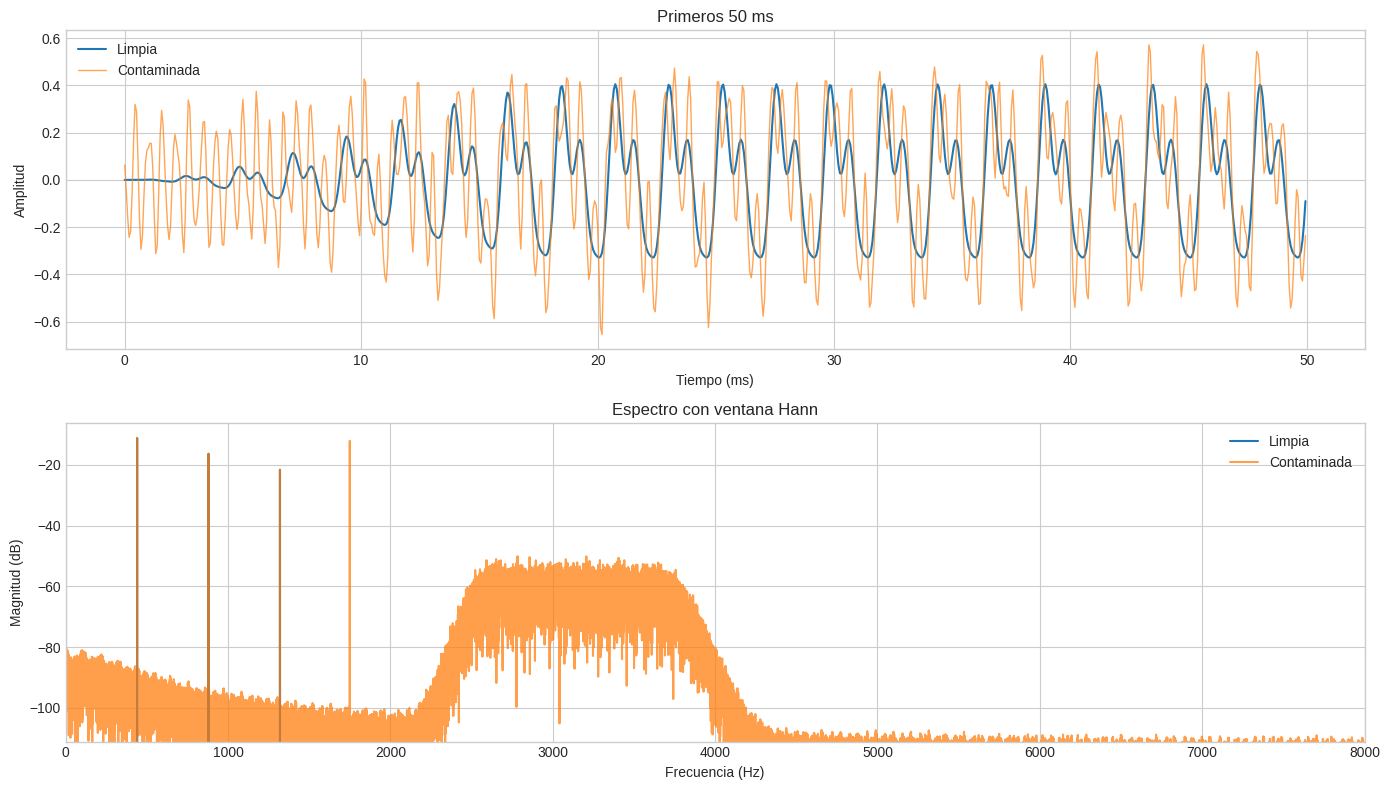

In [5]:
if FS < 2*max(FRECUENCIAS_UTILES + [FRECUENCIA_INTERFERENCIA, BANDA_RUIDO[1]]):
    raise ValueError('La configuración viola Nyquist. Aumente FS o reduzca las frecuencias.')

t = np.arange(int(FS*DURACION))/FS
clean = generar_limpia(TIPO_SENAL,t,FRECUENCIAS_UTILES,AMPLITUDES_UTILES,FASES_UTILES_GRADOS,rng)
clean = fade(clean,FS,FADE_MS)
noise_raw = generar_ruido(TIPO_RUIDO,t,FS,FRECUENCIA_INTERFERENCIA,BANDA_RUIDO,NUM_IMPULSOS,rng)
noise = escalar_ruido_para_snr(clean,noise_raw,SNR_OBJETIVO_DB)
noisy = clean + noise
[clean, noise, noisy], gain = normalizar_conjunto(clean,noise,noisy,peak=PICO_MAXIMO)
snr_real = snr_db(clean,noisy)
print(f'Muestras: {len(t):,} | SNR obtenida: {snr_real:.3f} dB | Ganancia común: {gain:.5f}')

view = min(len(t),int(.05*FS))
f1,m1 = espectro(clean,FS); f2,m2 = espectro(noisy,FS)
fig,ax = plt.subplots(2,1,figsize=(14,8))
ax[0].plot(t[:view]*1000,clean[:view],label='Limpia',lw=1.5)
ax[0].plot(t[:view]*1000,noisy[:view],label='Contaminada',alpha=.7,lw=1)
ax[0].set(xlabel='Tiempo (ms)',ylabel='Amplitud',title='Primeros 50 ms'); ax[0].legend()
ax[1].plot(f1,m1,label='Limpia'); ax[1].plot(f2,m2,label='Contaminada',alpha=.75)
ax[1].set_xlim(0,FS/2); ax[1].set_ylim(max(-120,np.max(m2)-100),np.max(m2)+5)
ax[1].set(xlabel='Frecuencia (Hz)',ylabel='Magnitud (dB)',title='Espectro con ventana Hann'); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Escucha
La referencia limpia se incluye para evaluación docente. Para la defensa puede reproducirse únicamente la señal contaminada hacia el ADC del sistema.

In [6]:
print('Referencia limpia')
display(Audio(clean,rate=FS,normalize=False))
print('Entrada contaminada para el sistema')
display(Audio(noisy,rate=FS,normalize=False))

Referencia limpia


Entrada contaminada para el sistema


## 6. Exportación
Crea archivos PCM mono de 16 bits. Todos usan la misma ganancia, por lo que las relaciones de amplitud y la SNR se conservan. El JSON permite repetir y auditar la prueba.

In [7]:
if CARPETA_SALIDA.exists(): shutil.rmtree(CARPETA_SALIDA)
CARPETA_SALIDA.mkdir(parents=True)
def pcm16(x): return np.int16(np.clip(x,-1,1)*32767)
wavfile.write(CARPETA_SALIDA/'01_referencia_limpia.wav',FS,pcm16(clean))
wavfile.write(CARPETA_SALIDA/'02_ruido.wav',FS,pcm16(noise))
wavfile.write(CARPETA_SALIDA/'03_entrada_contaminada.wav',FS,pcm16(noisy))
np.savetxt(CARPETA_SALIDA/'muestras_referencia.csv',np.column_stack([t,clean,noise,noisy]),
           delimiter=',',header='tiempo_s,limpia,ruido,contaminada',comments='')
metadata = {
 'nombre_prueba':NOMBRE_PRUEBA,'modo':MODO,'semilla':int(SEMILLA),'fs_Hz':int(FS),
 'duracion_s':float(DURACION),'tipo_senal':TIPO_SENAL,'frecuencias_utiles_Hz':[float(v) for v in FRECUENCIAS_UTILES],
 'amplitudes_utiles':[float(v) for v in AMPLITUDES_UTILES],'fases_grados':[float(v) for v in FASES_UTILES_GRADOS],
 'tipo_ruido':TIPO_RUIDO,'snr_objetivo_dB':float(SNR_OBJETIVO_DB),'snr_obtenida_dB':float(snr_real),
 'frecuencia_interferencia_Hz':float(FRECUENCIA_INTERFERENCIA),'banda_ruido_Hz':[float(v) for v in BANDA_RUIDO],
 'numero_impulsos':int(NUM_IMPULSOS),'pico_maximo':float(PICO_MAXIMO),'ganancia_comun':float(gain)
}
with open(CARPETA_SALIDA/'metadatos_prueba.json','w',encoding='utf-8') as f: json.dump(metadata,f,indent=2,ensure_ascii=False)
with open(CARPETA_SALIDA/'LEAME.txt','w',encoding='utf-8') as f:
    f.write('03_entrada_contaminada.wav: señal que se aplica al sistema.\n01_referencia_limpia.wav: referencia reservada para calcular métricas.\n02_ruido.wav: componente de ruido aislada.\n')
zip_path = CARPETA_SALIDA.parent/f'{NOMBRE_PRUEBA}.zip'
if zip_path.exists(): zip_path.unlink()
with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as z:
    for p in CARPETA_SALIDA.iterdir(): z.write(p,arcname=p.name)
print(f'Archivos exportados en: {CARPETA_SALIDA}')
print(f'ZIP para descargar: {zip_path}')
display(metadata)

Archivos exportados en: /kaggle/working/tonos_defensa
ZIP para descargar: /kaggle/working/defensa_grupo_01.zip


{'nombre_prueba': 'defensa_grupo_01',
 'modo': 'manual',
 'semilla': 20260918,
 'fs_Hz': 16000,
 'duracion_s': 6.0,
 'tipo_senal': 'multitono',
 'frecuencias_utiles_Hz': [440.0, 880.0, 1320.0],
 'amplitudes_utiles': [1.0, 0.55, 0.3],
 'fases_grados': [0.0, 35.0, -50.0],
 'tipo_ruido': 'mixto',
 'snr_objetivo_dB': 2.0,
 'snr_obtenida_dB': 2.000000000000021,
 'frecuencia_interferencia_Hz': 1750.0,
 'banda_ruido_Hz': [2500.0, 3800.0],
 'numero_impulsos': 10,
 'pico_maximo': 0.8,
 'ganancia_comun': 0.2779276200604859}

## Uso sugerido durante la defensa
1. Defina una semilla distinta por grupo y ejecute todo el notebook.
2. Conserve `01_referencia_limpia.wav` y `metadatos_prueba.json` como información docente.
3. Reproduzca `03_entrada_contaminada.wav` hacia el ADC, comenzando con volumen bajo.
4. Solicite al grupo diagnosticar el ruido, ajustar su sistema y mostrar ambas salidas.
5. Capture las salidas y compárelas contra la referencia con MSE, SNR, energía, atenuación y latencia.
6. Si desea exactamente el mismo caso otra vez, reutilice la semilla y la configuración guardada.

## Extensión para la Tarea 1 — sección 2.2
En esta sección procesamos de forma conjunta tres casos mediante las funciones del generador. Las señales se exportan a `2_2_generacionsenales/pruebas/`. Se emplean 8192 muestras y bloques de procesamiento de 1024 muestras.

In [ ]:
from pathlib import Path
import json
import numpy as np
from scipy.io import wavfile
from scipy.signal import butter, sosfiltfilt
import matplotlib.pyplot as plt

FS_22, N_BLOQUE_22, L_22 = 8000, 1024, 8192
CASOS_22 = [
    ('caso_1', 'tonal', 2150, None, 0.0, 202601),
    ('caso_2', 'blanco', None, None, 5.0, 202602),
    ('caso_3', 'banda', None, (900,1300), 3.0, 202603),
]
BASE_22 = Path('2_2_generacionsenales/pruebas')
BASE_22.mkdir(parents=True, exist_ok=True)
for nombre, tipo, interferencia, banda, snr_obj, semilla in CASOS_22:
    rng_22 = np.random.default_rng(semilla)
    tiempo = np.arange(L_22)/FS_22
    limpia = generar_limpia('multitono', tiempo, [300,700,1100], [1,.55,.30], [0,35,-50], rng_22)
    limpia = fade(limpia, FS_22, 20)
    if tipo == 'tonal':
        ruido_bruto = np.sin(2*np.pi*interferencia*tiempo + rng_22.uniform(-np.pi,np.pi))
    elif tipo == 'blanco':
        ruido_bruto = rng_22.standard_normal(L_22)
    else:
        ruido_bruto = ruido_banda(L_22, FS_22, banda, rng_22)
    ruido = escalar_ruido_para_snr(limpia, ruido_bruto, snr_obj)
    contaminada = limpia + ruido
    (limpia, ruido, contaminada), ganancia = normalizar_conjunto(limpia, ruido, contaminada, peak=0.8)
    snr_real = snr_db(limpia, contaminada)
    assert abs(snr_real-snr_obj) < 1e-8
    carpeta = BASE_22/nombre
    carpeta.mkdir(parents=True, exist_ok=True)
    for archivo, senal in [('01_referencia_limpia.wav',limpia),('02_ruido.wav',ruido),('03_entrada_contaminada.wav',contaminada)]:
        wavfile.write(carpeta/archivo, FS_22, np.int16(np.clip(senal,-1,1)*32767))
    np.savez(carpeta/'muestras_exactas.npz', limpia=limpia, ruido=ruido, contaminada=contaminada, fs=FS_22)
    config = dict(semilla=semilla, fs_Hz=FS_22, N_bloque=N_BLOQUE_22, duracion_s=L_22/FS_22,
                  frecuencias_utiles_Hz=[300,700,1100], tipo_ruido=tipo,
                  frecuencia_interferencia_Hz=interferencia, banda_ruido_Hz=banda,
                  snr_objetivo_dB=snr_obj, snr_obtenida_dB=float(snr_real))
    (carpeta/'metadatos_prueba.json').write_text(json.dumps(config,indent=2,ensure_ascii=False))
    print(nombre, 'SNR objetivo:',snr_obj,'SNR obtenida:',round(snr_real,9))


caso_1 SNR objetivo: 0.0 SNR obtenida: 0.0
caso_2 SNR objetivo: 5.0 SNR obtenida: 5.0
caso_3 SNR objetivo: 3.0 SNR obtenida: 3.0


### Generación de gráficas sección 2.2
Para esta sección se generan las gráficas de señales en el tiempo, magnitud espectral, fase espectral y energía or bandas la cuales se guardan divididas según el caso en `pruebas/resultados/figuras` 


Generando gráficas del caso 1
Variables disponibles: ['limpia', 'ruido', 'contaminada', 'fs']


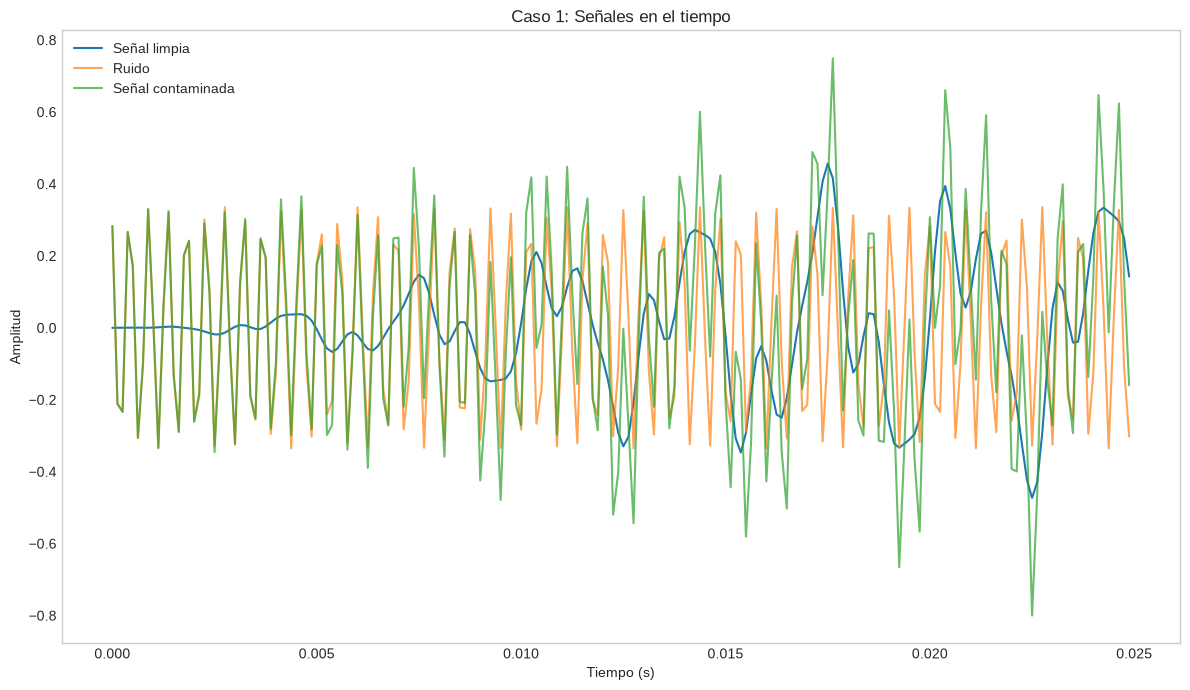

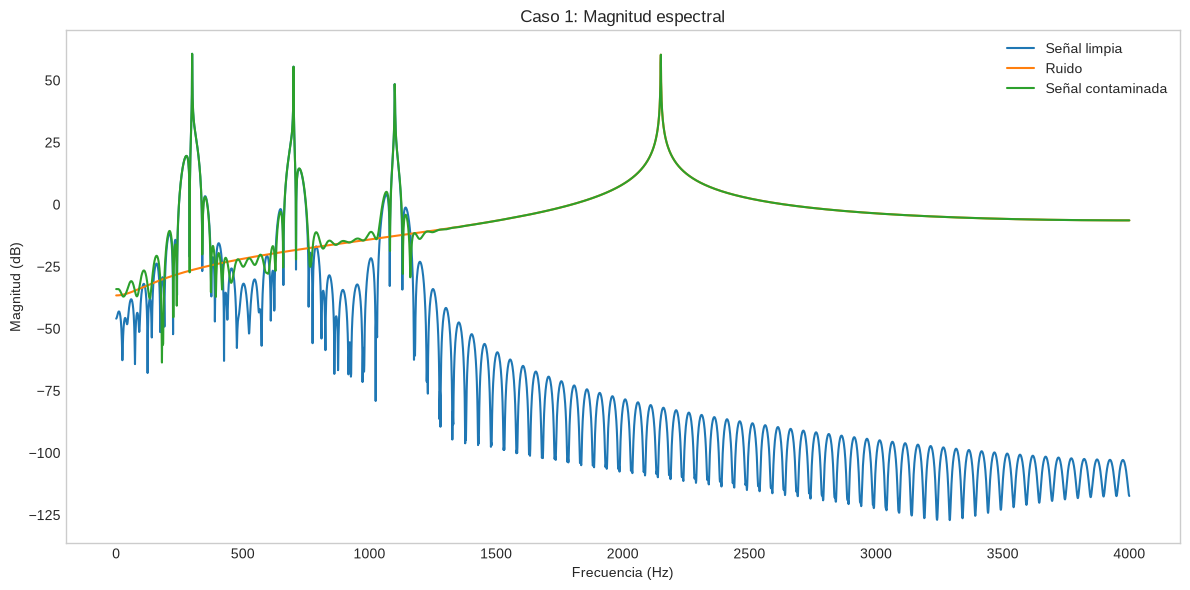

/tmp/ipykernel_55023/519131180.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


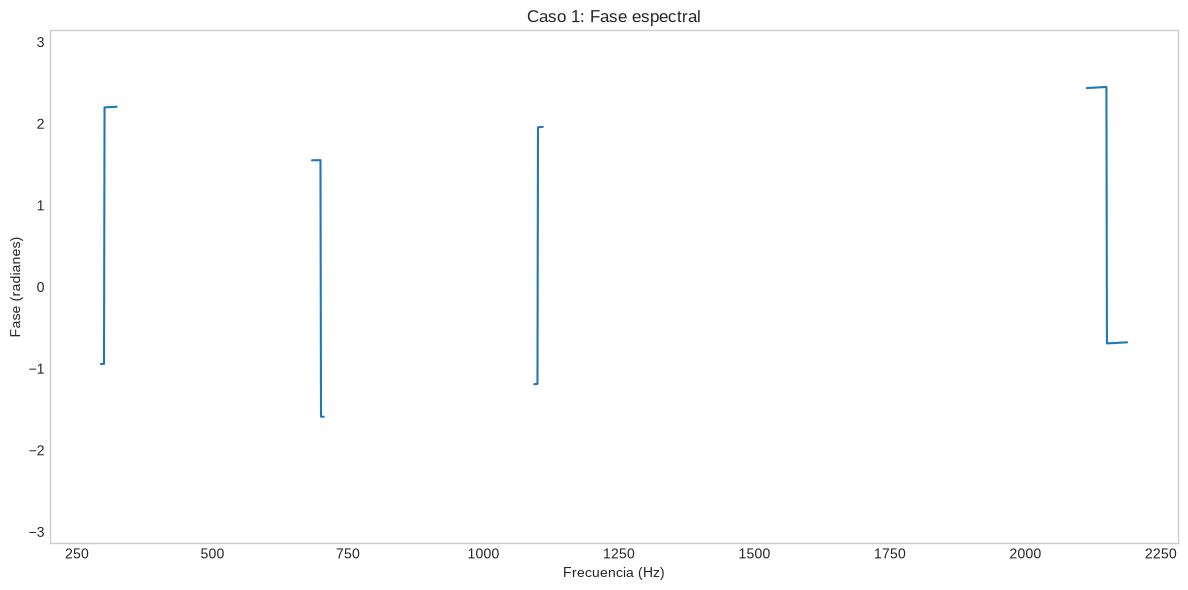

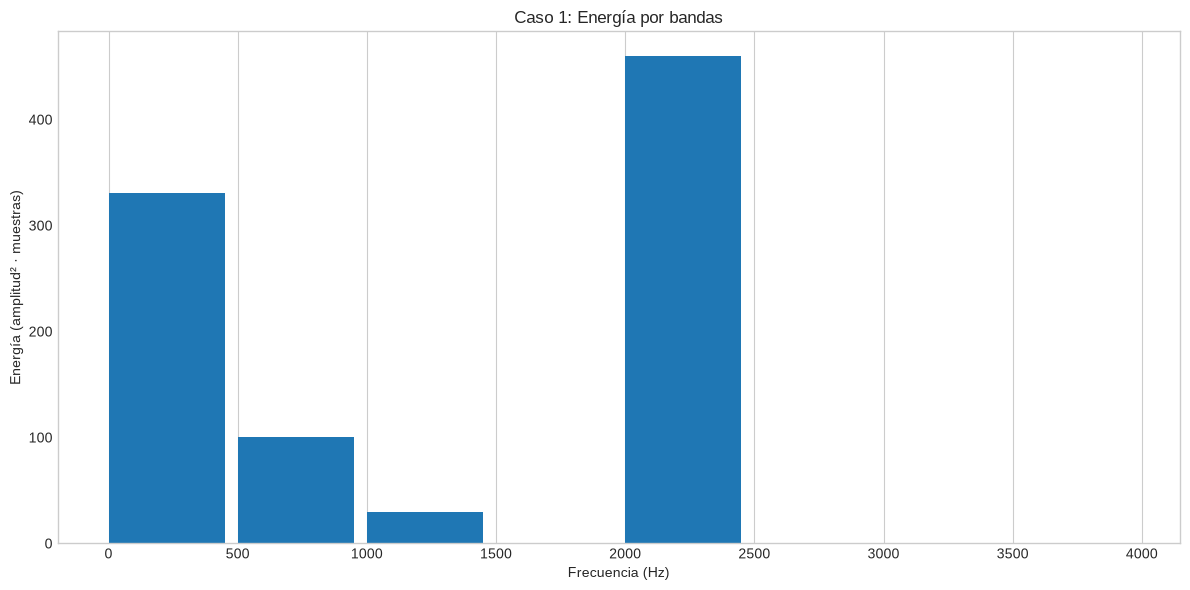


Generando gráficas del caso 2
Variables disponibles: ['limpia', 'ruido', 'contaminada', 'fs']


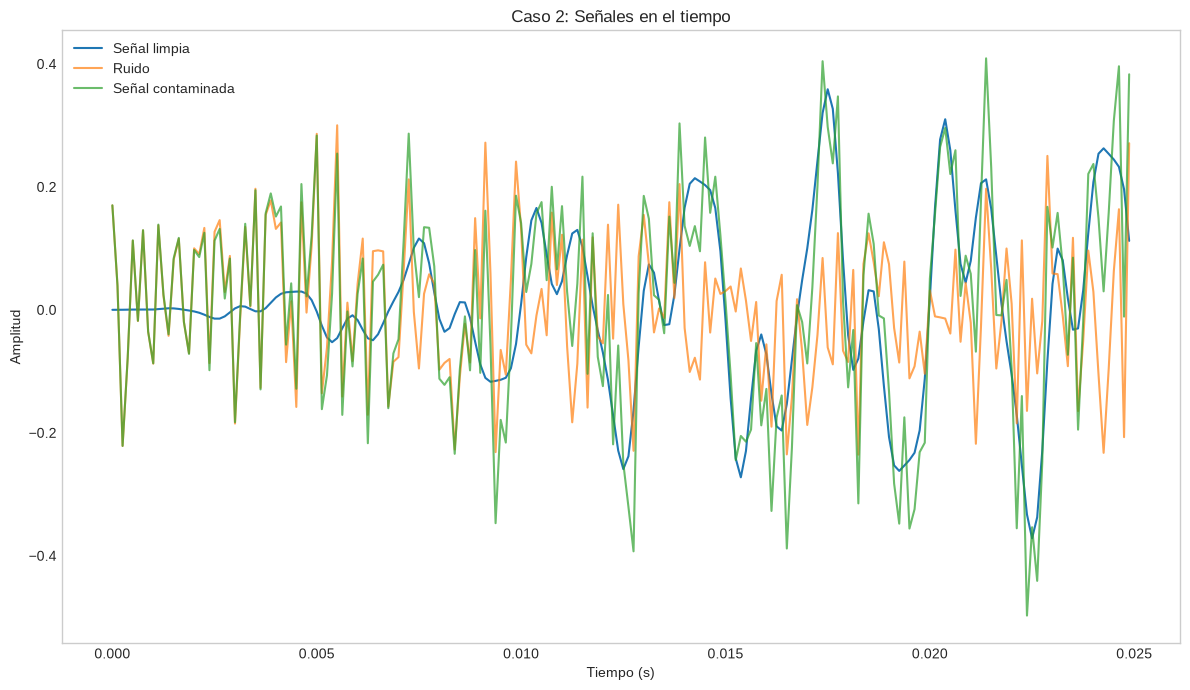

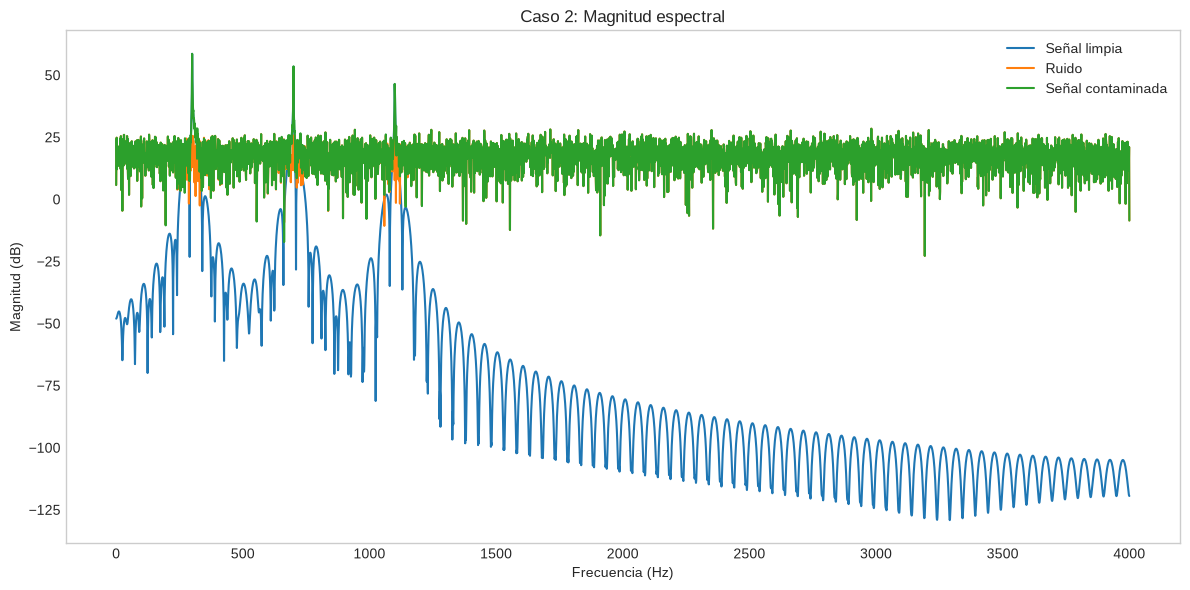

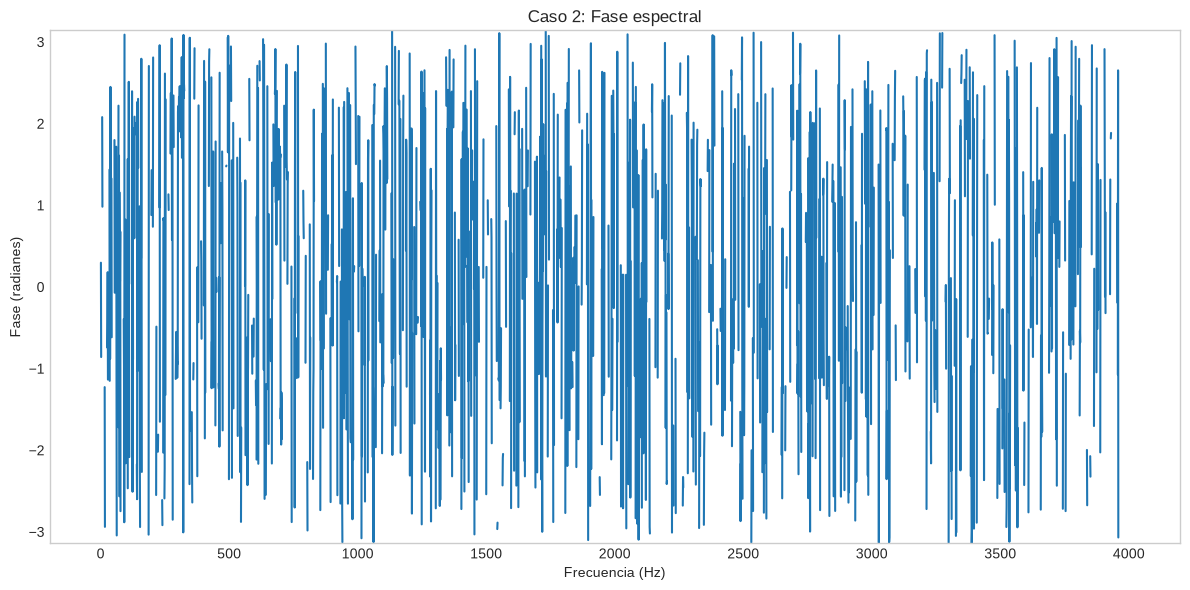

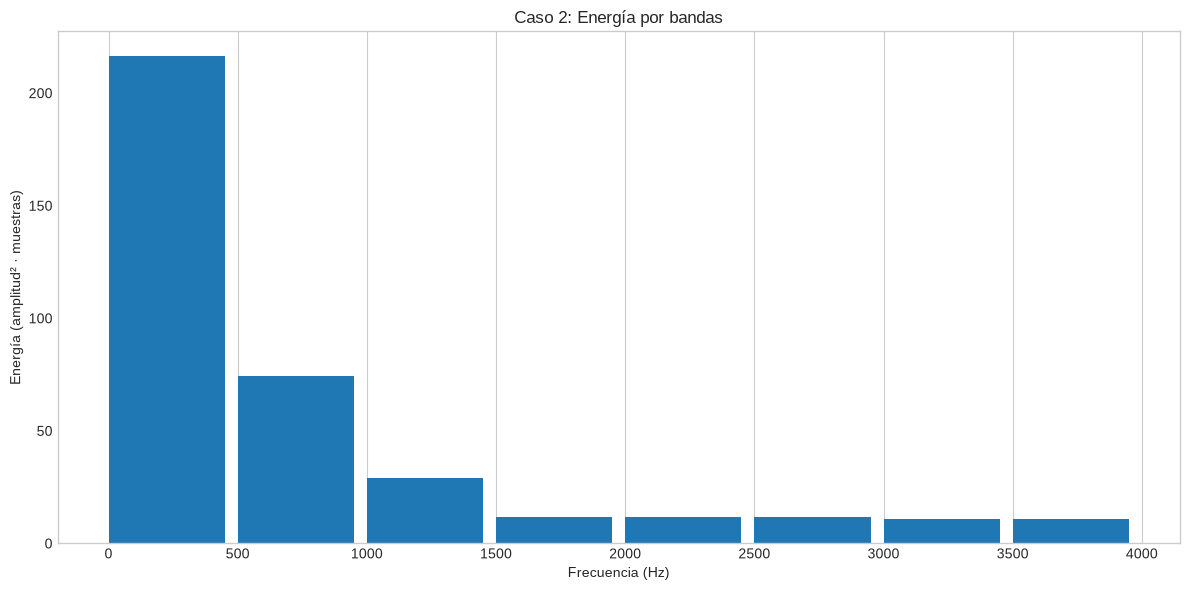


Generando gráficas del caso 3
Variables disponibles: ['limpia', 'ruido', 'contaminada', 'fs']


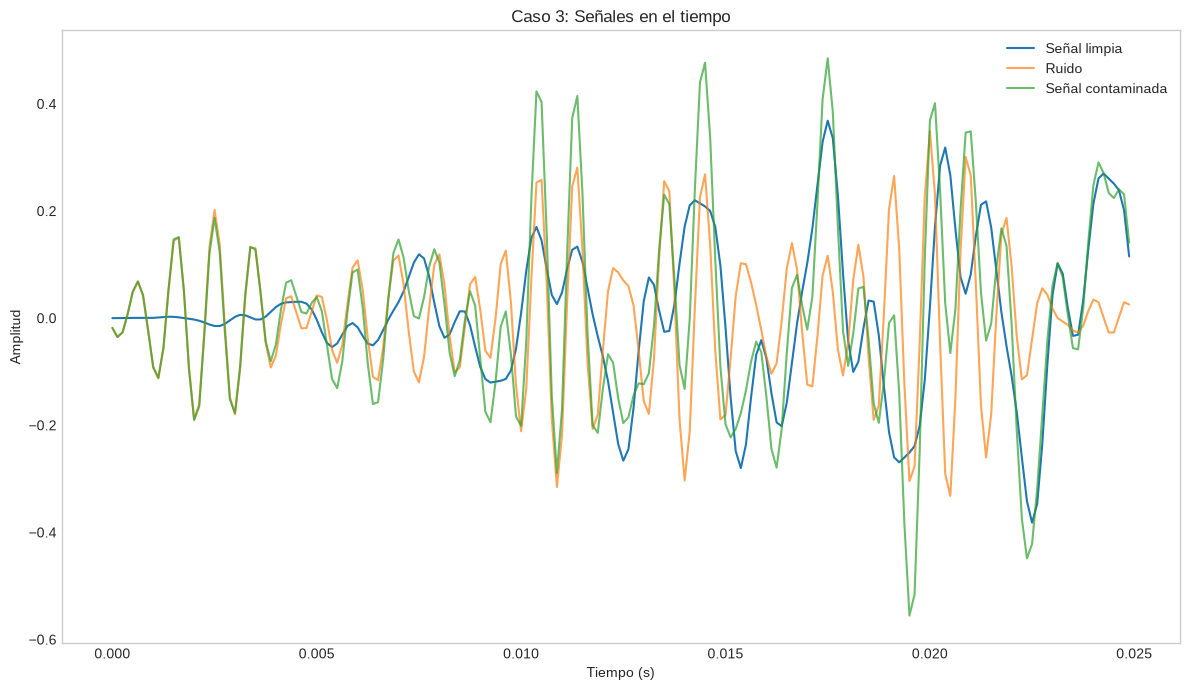

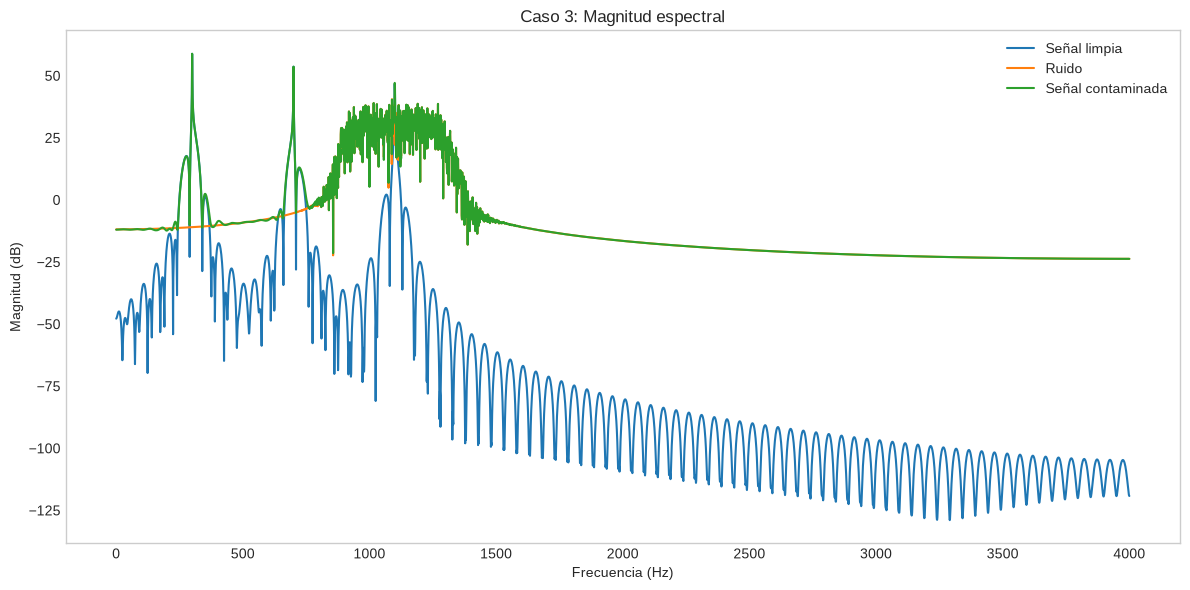

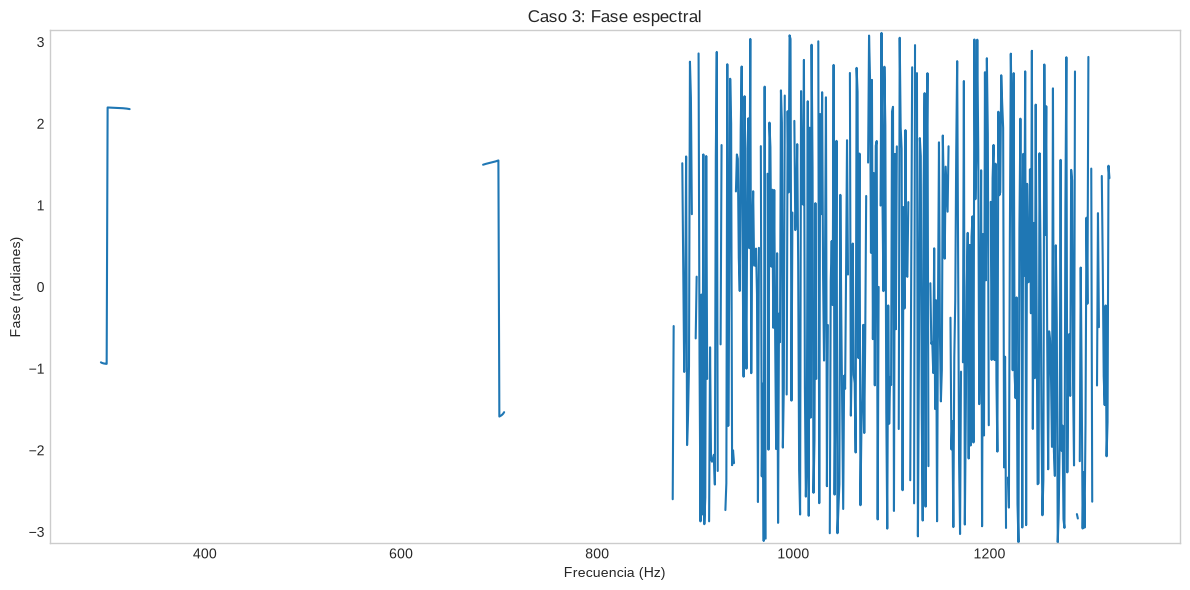

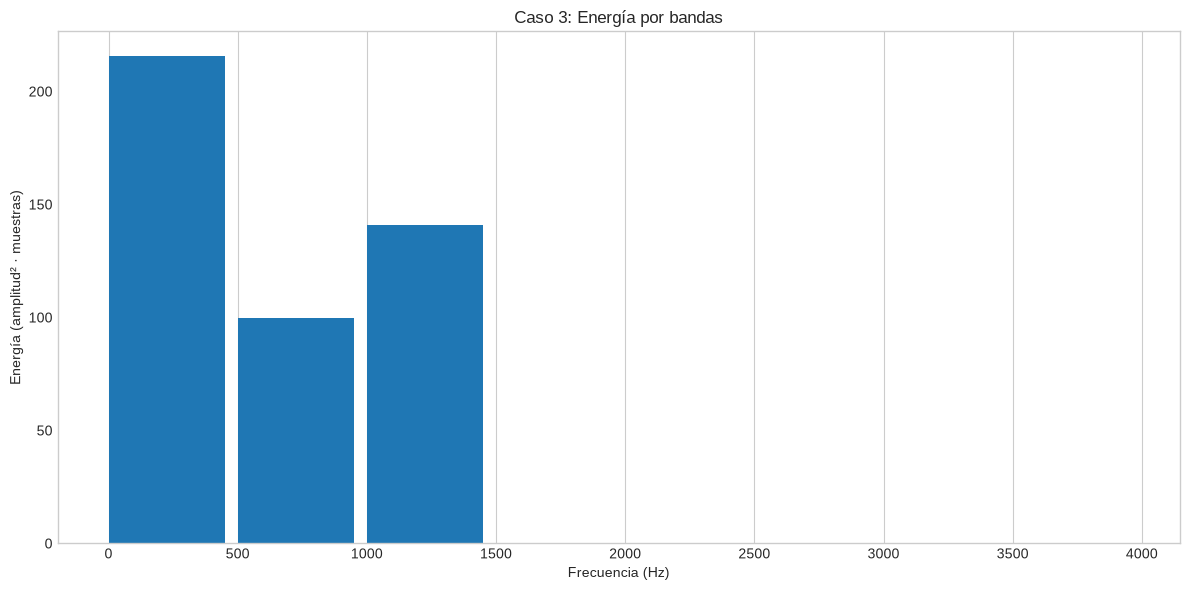


Todas las gráficas fueron generadas.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Parámetros
FS = 8000
BASE = Path("2_2_generacionsenales/pruebas")

SALIDA = Path("2_2_generacionsenales/resultados/figuras")
SALIDA.mkdir(parents=True, exist_ok=True)


def graficar_caso(numero):

    # Crear carpeta para las gráficas de este caso
    carpeta_figuras = SALIDA / f"caso_{numero}"

    carpeta_figuras.mkdir(
        parents=True,
        exist_ok=True
    )

    # Cargar las señales originales
    ruta = BASE / f"caso_{numero}" / "muestras_exactas.npz"

    datos = np.load(ruta)

    print("Variables disponibles:", datos.files)

    # Obtener las señales
    limpia = datos["limpia"]
    ruido = datos["ruido"]
    contaminada = datos["contaminada"]

    N = len(limpia)
    tiempo = np.arange(N) / FS


    # GRÁFICA 1: DOMINIO TEMPORAL
    plt.figure(figsize=(12, 7))

    muestras = 200

    plt.plot(
        tiempo[:muestras],
        limpia[:muestras],
        label="Señal limpia"
    )

    plt.plot(
        tiempo[:muestras],
        ruido[:muestras],
        label="Ruido",
        alpha=0.7
    )

    plt.plot(
        tiempo[:muestras],
        contaminada[:muestras],
        label="Señal contaminada",
        alpha=0.7
    )

    plt.title(f"Caso {numero}: Señales en el tiempo")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.grid()

    plt.tight_layout()

    plt.savefig(
    carpeta_figuras / "temporal.png",
    dpi=300
)

    plt.show()

    # GRÁFICA 2: MAGNITUD ESPECTRAL

    frecuencias = np.fft.rfftfreq(N, 1 / FS)

    fft_limpia = np.fft.rfft(limpia)
    fft_ruido = np.fft.rfft(ruido)
    fft_contaminada = np.fft.rfft(contaminada)

    plt.figure(figsize=(12, 6))

    plt.plot(
        frecuencias,
        20 * np.log10(np.abs(fft_limpia) + 1e-12),
        label="Señal limpia"
    )

    plt.plot(
        frecuencias,
        20 * np.log10(np.abs(fft_ruido) + 1e-12),
        label="Ruido"
    )

    plt.plot(
        frecuencias,
        20 * np.log10(np.abs(fft_contaminada) + 1e-12),
        label="Señal contaminada"
    )

    plt.title(f"Caso {numero}: Magnitud espectral")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud (dB)")
    plt.legend()
    plt.grid()

    plt.tight_layout()

    plt.savefig(
        carpeta_figuras / "magnitud.png",
        dpi=300
    )

    plt.show()

    # GRÁFICA 3: FASE ESPECTRAL
    umbral = 0.01 * np.max(np.abs(fft_contaminada))

    fase = np.angle(fft_contaminada)

    fase[np.abs(fft_contaminada) < umbral] = np.nan

    plt.figure(figsize=(12, 6))

    plt.plot(
        frecuencias,
        fase
    )

    plt.ylim(-np.pi, np.pi)
    plt.legend()

    plt.title(f"Caso {numero}: Fase espectral")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Fase (radianes)")
    plt.grid()

    plt.tight_layout()

    plt.savefig(
    carpeta_figuras / "fase.png",
    dpi=300
    )

    plt.show()


    # GRÁFICA 4: ENERGÍA POR BANDAS
    
    # Bandas de 500 Hz
    bandas = np.arange(0, FS / 2 + 500, 500)

    potencia = np.abs(fft_contaminada) ** 2 / N

    pesos = np.ones_like(potencia)
    pesos[1:-1] = 2

    energia_bandas = []

    for i in range(len(bandas) - 1):

        if i == len(bandas) - 2:
            mascara = (
                (frecuencias >= bandas[i]) &
                (frecuencias <= bandas[i + 1])
            )
        else:
            mascara = (
                (frecuencias >= bandas[i]) &
                (frecuencias < bandas[i + 1])
            )

        energia = np.sum(potencia[mascara] * pesos[mascara])

        energia_bandas.append(energia)

    plt.figure(figsize=(12, 6))

    plt.bar(
        bandas[:-1],
        energia_bandas,
        width=450,
        align="edge"
    )

    plt.title(f"Caso {numero}: Energía por bandas")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Energía (amplitud² · muestras)")
    plt.grid(axis="y")

    plt.tight_layout()

    plt.savefig(
    carpeta_figuras / "energia.png",
    dpi=300
    )

    plt.show()



# GENERAR GRÁFICAS PARA LOS TRES CASOS

for caso in [1, 2, 3]:

    print(f"\nGenerando gráficas del caso {caso}")

    graficar_caso(caso)

print("\nTodas las gráficas fueron generadas.")

### Identificación automática del ruido

Se realiza un análisis espectral de las señales generadas para identificar las características de las interferencias.

Se utiliza la Transformada Rápida de Fourier (FFT) para determinar la distribución de energía del ruido y localizar frecuenciales contaminadas.

In [2]:
import numpy as np
import json
from pathlib import Path

# Parámetros
FS = 8000

BASE = Path("2_2_generacionsenales/pruebas")

SALIDA_RUIDO = Path(
    "2_2_generacionsenales/resultados/identificacion_ruido"
)

SALIDA_RUIDO.mkdir(
    parents=True,
    exist_ok=True
)


def analizar_ruido(numero):

    # Cargar las señales
    ruta = BASE / f"caso_{numero}" / "muestras_exactas.npz"

    datos = np.load(ruta)

    ruido = datos["ruido"]

    N = len(ruido)

    # Calcular FFT
    frecuencias = np.fft.rfftfreq(N, 1 / FS)

    espectro = np.abs(np.fft.rfft(ruido))

    potencia = espectro**2

    # Diccionario para almacenar resultados
    resultados = {
        "caso": numero,
        "frecuencia_muestreo_Hz": FS,
        "numero_muestras": N,
        "resolucion_frecuencial_Hz": FS / N
    }

    print(f"\n========== CASO {numero} ==========")

    # CASO 1: INTERFERENCIA SINUSOIDAL
    if numero == 1:

        indice = np.argmax(espectro[1:]) + 1

        frecuencia = float(frecuencias[indice])

        resultados["tipo_ruido"] = "Interferencia sinusoidal"

        resultados["frecuencia_detectada_Hz"] = frecuencia

        resultados["frecuencia_configurada_Hz"] = 2150

        resultados["error_absoluto_Hz"] = abs(
            frecuencia - 2150
        )

        print("Tipo: Interferencia sinusoidal")

        print(
            f"Frecuencia detectada: {frecuencia:.2f} Hz"
        )

        print(
            f"Error absoluto: {resultados['error_absoluto_Hz']:.2f} Hz"
        )

    # CASO 2: RUIDO BLANCO GAUSSIANO
    elif numero == 2:

        bandas = np.arange(0, FS / 2 + 500, 500)

        energias = []

        for i in range(len(bandas) - 1):

            mascara = (
                (frecuencias >= bandas[i]) &
                (frecuencias < bandas[i + 1])
            )

            energia = float(
                np.sum(potencia[mascara])
            )

            energias.append(energia)

        energias = np.array(energias)

        coeficiente_variacion = float(
            np.std(energias) / np.mean(energias)
        )

        resultados["tipo_ruido"] = "Ruido blanco gaussiano"

        resultados["energia_por_bandas"] = {}

        for i, energia in enumerate(energias):

            nombre_banda = (
                f"{int(bandas[i])}-{int(bandas[i+1])} Hz"
            )

            resultados["energia_por_bandas"][nombre_banda] = float(
                energia
            )

        resultados["coeficiente_variacion"] = (
            coeficiente_variacion
        )

        resultados["coeficiente_variacion_porcentaje"] = (
            coeficiente_variacion * 100
        )

        print("Tipo: Ruido blanco gaussiano")

        print("Distribución de energía por bandas:")

        for banda, energia in resultados["energia_por_bandas"].items():

            print(f"{banda}: {energia:.2f}")

        print(
            f"Coeficiente de variación: "
            f"{coeficiente_variacion:.4f}"
        )

    # CASO 3: RUIDO DE BANDA LIMITADA
    elif numero == 3:

        ventana = 101

        kernel = np.ones(ventana) / ventana

        potencia_suavizada = np.convolve(
            potencia,
            kernel,
            mode="same"
        )

        umbral = 0.1 * np.max(potencia_suavizada)

        indices = np.where(
            potencia_suavizada > umbral
        )[0]

        resultados["tipo_ruido"] = "Ruido de banda limitada"

        resultados["banda_configurada_Hz"] = [
            900,
            1300
        ]

        resultados["ventana_suavizado"] = ventana

        resultados["umbral_relativo"] = 0.1

        if len(indices) > 0:

            f_inicio = float(frecuencias[indices[0]])

            f_fin = float(frecuencias[indices[-1]])

            resultados["banda_detectada_Hz"] = [
                f_inicio,
                f_fin
            ]

            resultados["error_limite_inferior_Hz"] = abs(
                f_inicio - 900
            )

            resultados["error_limite_superior_Hz"] = abs(
                f_fin - 1300
            )

            print("Tipo: Ruido de banda limitada")

            print(
                f"Banda detectada: "
                f"{f_inicio:.2f} - {f_fin:.2f} Hz"
            )

        else:

            resultados["banda_detectada_Hz"] = None

            print("No se detectó una banda dominante.")

    # GUARDAR RESULTADOS

    carpeta_caso = SALIDA_RUIDO / f"caso_{numero}"

    carpeta_caso.mkdir(
        parents=True,
        exist_ok=True
    )

    archivo_json = carpeta_caso / "resultados.json"

    with open(
        archivo_json,
        "w",
        encoding="utf-8"
    ) as archivo:

        json.dump(
            resultados,
            archivo,
            indent=4,
            ensure_ascii=False
        )

    print(f"Resultados guardados en: {archivo_json}")

    return resultados


# EJECUTAR LOS TRES CASOS

resultados_casos = {}

for caso in [1, 2, 3]:

    resultados_casos[caso] = analizar_ruido(caso)

print("\nTodos los resultados fueron guardados correctamente.")


========== CASO 1 ==========
Tipo: Interferencia sinusoidal
Frecuencia detectada: 2150.39 Hz
Error absoluto: 0.39 Hz
Resultados guardados en: 2_2_generacionsenales/resultados/identificacion_ruido/caso_1/resultados.json

========== CASO 2 ==========
Tipo: Ruido blanco gaussiano
Distribución de energía por bandas:
0-500 Hz: 46806.76
500-1000 Hz: 46203.09
1000-1500 Hz: 44661.48
1500-2000 Hz: 48637.45
2000-2500 Hz: 47463.58
2500-3000 Hz: 47319.99
3000-3500 Hz: 43650.49
3500-4000 Hz: 44065.96
Coeficiente de variación: 0.0364
Resultados guardados en: 2_2_generacionsenales/resultados/identificacion_ruido/caso_2/resultados.json

========== CASO 3 ==========
Tipo: Ruido de banda limitada
Banda detectada: 870.12 - 1327.15 Hz
Resultados guardados en: 2_2_generacionsenales/resultados/identificacion_ruido/caso_3/resultados.json

Todos los resultados fueron guardados correctamente.
